# Airline Passenger Satisfaction — Machine Learning

**Objective:** Predict whether a passenger is **satisfied** or **neutral/dissatisfied** from the passenger and service information.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [19]:
DATA_FILE = "Airline_Satisfaction_Cleaned.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())
df.head()

Dataset shape: (129487, 25)
Column names:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'satisfied_binary', 'total_delay']


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,satisfied_binary,total_delay
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,0,43.0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,0,7.0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied,1,0.0
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,0,20.0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied,1,0.0


## target column


In [20]:
df['target'] = (df['satisfaction'] == 'satisfied').astype(int)

print(df['target'].value_counts())
print()
print("Share satisfied:", round(df['target'].mean() * 100, 1), "%")

target
0    73225
1    56262
Name: count, dtype: int64

Share satisfied: 43.4 %


In [21]:
leakage_columns = [
    "satisfaction",
    "target",
    "satisfied_binary",
    "satisfaction_binary",
    "satisfaction_encoded",
    "target_binary"
]


identifier_columns = ["id", "ID", "Unnamed: 0"]

columns_to_drop = [
    col for col in leakage_columns + identifier_columns
    if col in df.columns
]

X = df.drop(columns=columns_to_drop).copy()

print("Columns excluded:", columns_to_drop)
print("Number of raw input columns:", X.shape[1])
print("Target included in X:", any(col in X.columns for col in leakage_columns))

if X.shape[1] == 0:
    raise ValueError("No input features remain after removing target/leakage columns.")

X.head()

Columns excluded: ['satisfaction', 'target', 'satisfied_binary']
Number of raw input columns: 23
Target included in X: False


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,43.0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,7.0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,0.0
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,20.0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,0.0


In [22]:
y = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

print(y.value_counts())

satisfaction
0    73225
1    56262
Name: count, dtype: int64


##  train/test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])
print("Training satisfied share:", f"{y_train.mean() * 100:.1f}%")
print("Testing satisfied share :", f"{y_test.mean() * 100:.1f}%")

Training rows: 103589
Testing rows : 25898
Training satisfied share: 43.4%
Testing satisfied share : 43.5%


## Preprocessing

In [24]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))
print("Missing cells in training features before preprocessing:", int(X_train.isna().sum().sum()))
print("Missing cells in test features before preprocessing:", int(X_test.isna().sum().sum()))

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Numeric columns: 19
Categorical columns: 4
Missing cells in training features before preprocessing: 0
Missing cells in test features before preprocessing: 0
Processed training shape: (103589, 24)
Processed test shape: (25898, 24)


## Logistic Regression

In [25]:
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_processed, y_train)

log_pred = log_model.predict(X_test_processed)
log_acc = accuracy_score(y_test, log_pred)

print(f"Logistic Regression test accuracy: {log_acc:.1%}")
print(f"Training accuracy: {log_model.score(X_train_processed, y_train):.1%}")
print("\nClassification report:")
print(classification_report(
    y_test,
    log_pred,
    labels=[0, 1],
    target_names=["Neutral/dissatisfied", "Satisfied"],
    zero_division=0
))

Logistic Regression test accuracy: 87.4%
Training accuracy: 87.4%

Classification report:
                      precision    recall  f1-score   support

Neutral/dissatisfied       0.88      0.90      0.89     14645
           Satisfied       0.87      0.84      0.85     11253

            accuracy                           0.87     25898
           macro avg       0.87      0.87      0.87     25898
        weighted avg       0.87      0.87      0.87     25898



## Random Forest

In [26]:

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest test accuracy: {rf_acc:.1%}")
print(f"Training accuracy: {rf_model.score(X_train_processed, y_train):.1%}")

print("\nClassification report:")
print(classification_report(
    y_test,
    rf_pred,
    labels=[0, 1],
    target_names=["Neutral/dissatisfied", "Satisfied"],
    zero_division=0
))

Random Forest test accuracy: 95.7%
Training accuracy: 96.6%

Classification report:
                      precision    recall  f1-score   support

Neutral/dissatisfied       0.95      0.97      0.96     14645
           Satisfied       0.96      0.94      0.95     11253

            accuracy                           0.96     25898
           macro avg       0.96      0.96      0.96     25898
        weighted avg       0.96      0.96      0.96     25898



## the models

In [27]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, log_pred),
        "Precision": precision_score(y_test, log_pred, zero_division=0),
        "Recall": recall_score(y_test, log_pred, zero_division=0),
        "F1-score": f1_score(y_test, log_pred, zero_division=0)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred, zero_division=0),
        "Recall": recall_score(y_test, rf_pred, zero_division=0),
        "F1-score": f1_score(y_test, rf_pred, zero_division=0)
    }
])

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.874,0.868,0.838,0.853
1,Random Forest,0.957,0.962,0.938,0.950


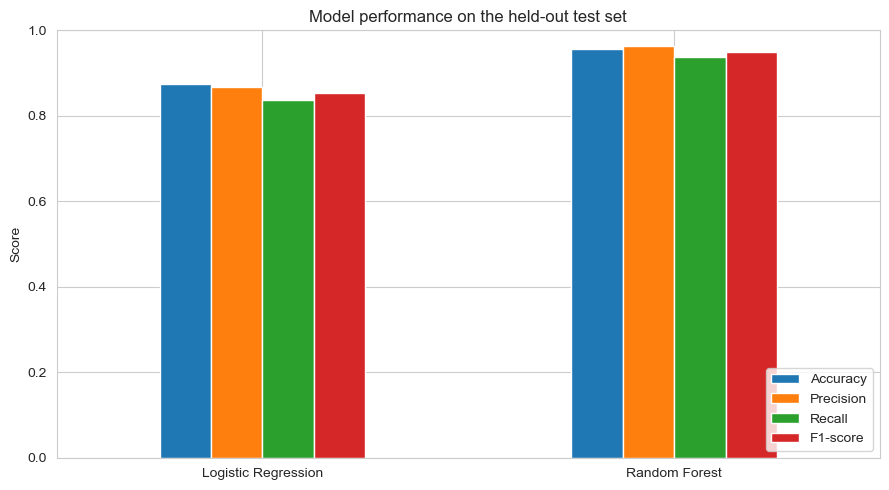

In [28]:
ax = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 1),
    rot=0
)
ax.set_title("Model performance on the held-out test set")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Confusion matrix

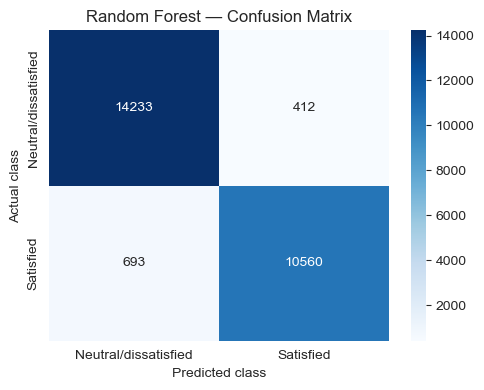

In [29]:
cm = confusion_matrix(y_test, rf_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neutral/dissatisfied", "Satisfied"],
    yticklabels=["Neutral/dissatisfied", "Satisfied"]
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## Random Forest feature importance

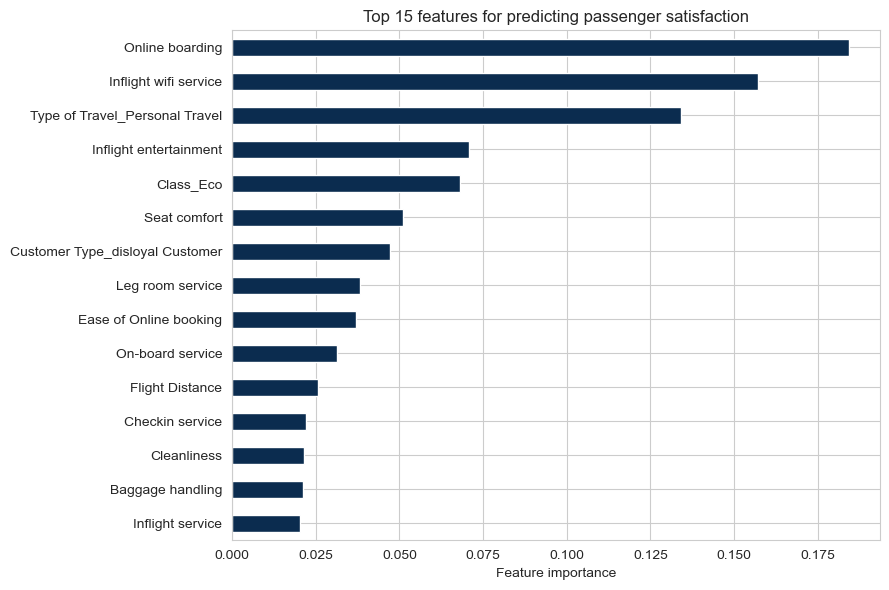

Online boarding                    0.184
Inflight wifi service              0.157
Type of Travel_Personal Travel     0.134
Inflight entertainment             0.071
Class_Eco                          0.068
Seat comfort                       0.051
Customer Type_disloyal Customer    0.047
Leg room service                   0.038
Ease of Online booking             0.037
On-board service                   0.031
dtype: float64

In [30]:
feature_names = preprocessor.get_feature_names_out()
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Make the labels easier to read.
importance.index = (
    importance.index
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

top15 = importance.head(15).sort_values()

plt.figure(figsize=(9, 6))
top15.plot(kind="barh", color="#0B2C4F")
plt.title("Top 15 features for predicting passenger satisfaction")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

importance.head(10).round(3)

In [31]:
# Check where the delay features rank, if those columns are present.
delay_positions = {
    feature: rank
    for rank, feature in enumerate(importance.index, start=1)
    if "delay" in feature.lower()
}

if delay_positions:
    print("Rank of delay features out of", len(importance), "processed features:")
    print(delay_positions)
else:
    print("No delay-related features were found in the processed feature names.")

Rank of delay features out of 24 processed features:
{'Arrival Delay in Minutes': 20, 'total_delay': 21, 'Departure Delay in Minutes': 23}


## Model Prediction Results

In [32]:
first_10 = X_test.iloc[:10]

actual = y_test.iloc[:10].astype(int).values
predicted = rf_model.predict(preprocessor.transform(first_10)).astype(int)

results = pd.DataFrame({
    "Actual": ["Satisfied" if x == 1 else "Neutral/dissatisfied" for x in actual],
    "Predicted": ["Satisfied" if x == 1 else "Neutral/dissatisfied" for x in predicted]
})

results

,Actual,Predicted
0,Neutral/dissatisfied,Neutral/dissatisfied
1,Neutral/dissatisfied,Neutral/dissatisfied
2,Neutral/dissatisfied,Neutral/dissatisfied
3,Neutral/dissatisfied,Neutral/dissatisfied
4,Neutral/dissatisfied,Neutral/dissatisfied
5,Neutral/dissatisfied,Neutral/dissatisfied
6,Satisfied,Satisfied
7,Neutral/dissatisfied,Neutral/dissatisfied
8,Satisfied,Satisfied
9,Neutral/dissatisfied,Satisfied


## conclusion

In [33]:
print("Rows used:", len(df))
print("Number of input columns before encoding:", X.shape[1])
print("Input contains satisfaction column:", "satisfaction" in X.columns)
print("Input contains satisfied_binary column:", "satisfied_binary" in X.columns)
print("Logistic Regression test accuracy:", f"{log_acc:.1%}")
print("Random Forest test accuracy:", f"{rf_acc:.1%}")

Rows used: 129487
Number of input columns before encoding: 23
Input contains satisfaction column: False
Input contains satisfied_binary column: False
Logistic Regression test accuracy: 87.4%
Random Forest test accuracy: 95.7%


The Airline Passenger Satisfaction dataset was analysed using EDA, Logistic Regression, and Random Forest. Random Forest performed better than Logistic Regression, achieving 95.7% test accuracy. The results show that machine learning can effectively predict passenger satisfaction using the available passenger and service-related features.